# Chargement et structuration du projet

In [4]:
# Imports de base
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Chemins principaux
root_path = r"C:\Users\chouh\Projet7"
data_path = os.path.join(root_path, "data")
artifacts_path = os.path.join(root_path, "artifacts")
api_path = os.path.join(root_path, "api")

# Ajout du dossier api au sys.path pour importer les classes perso
sys.path.append(api_path)

# Affichage large
pd.set_option('display.max_columns', None)

In [6]:
# Création des dossiers si nécessaires
for path in [data_path, artifacts_path, api_path]:
    os.makedirs(path, exist_ok=True)

print("✅ Structure de dossier vérifiée.")

✅ Structure de dossier vérifiée.


In [8]:
# Chargement des fichiers de base
train_file = os.path.join(data_path, "application_train.csv")
test_file = os.path.join(data_path, "application_test.csv")

df_train = pd.read_csv(train_file)
df_test = pd.read_csv(test_file)

print(f"📂 Données d'entraînement : {df_train.shape}")
print(f"📂 Données de test        : {df_test.shape}")

📂 Données d'entraînement : (307511, 122)
📂 Données de test        : (48744, 121)


In [10]:
# Vérification des colonnes et de la cible
print("✅ Colonnes train :", df_train.columns.tolist()[:10])
print("✅ TARGET présente :", "TARGET" in df_train.columns)
print("✅ ID colonne :", "SK_ID_CURR" in df_train.columns)

✅ Colonnes train : ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
✅ TARGET présente : True
✅ ID colonne : True


In [12]:
# Ajout de colonne temporaire pour séparer ensuite
df_train["source"] = "train"
df_test["source"] = "test"
df_test["TARGET"] = np.nan  # ajout pour homogénéiser

df_all = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)
print(f"🧩 Dataset fusionné : {df_all.shape}")

🧩 Dataset fusionné : (356255, 123)


# Prétraitement complet et création du pipeline

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from custom_preprocessing import CustomPreprocessor

# Création du pipeline
pipeline = Pipeline(steps=[
    ("preprocessing", FunctionTransformer(CustomPreprocessor().transform))
])

In [18]:
df_processed = pipeline.fit_transform(df_all)

print("Forme après transformation :", df_processed.shape)

Forme après transformation : (356251, 263)


C:\Users\chouh\Projet7\api\custom_preprocessing.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




In [20]:
df_processed.columns = df_processed.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [22]:
df_train_cleaned = df_processed[df_all['source'] == 'train'].copy()
df_test_cleaned = df_processed[df_all['source'] == 'test'].copy()

print("Train nettoyé :", df_train_cleaned.shape)
print("Test nettoyé :", df_test_cleaned.shape)

C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\3854685763.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_train_cleaned = df_processed[df_all['source'] == 'train'].copy()


Train nettoyé : (307507, 263)
Test nettoyé : (48744, 263)


C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\3854685763.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_test_cleaned = df_processed[df_all['source'] == 'test'].copy()


In [24]:
joblib.dump(pipeline, os.path.join(artifacts_path, "preprocessor_custom.pkl"))
print("Préprocesseur sauvegardé.")

Préprocesseur sauvegardé.


# Construction des jeux d’entraînement

In [27]:
# Suppression de la colonne source
df_train_cleaned = df_train_cleaned.drop(columns="source", errors="ignore")

# Séparation X / y
X = df_train_cleaned.drop(columns="TARGET")
y = df_train_cleaned["TARGET"]

print("X :", X.shape)
print("y :", y.shape)

X : (307507, 262)
y : (307507,)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train :", X_train.shape)
print("X_val   :", X_val.shape)

X_train : (246005, 262)
X_val   : (61502, 262)


In [31]:
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

In [33]:
# Ligne vide avec toutes les colonnes nécessaires pour l’API dynamique
template = X_train.iloc[[0]].copy()
template.iloc[0] = np.nan

joblib.dump(template, os.path.join(artifacts_path, "template_input.pkl"))
print("Template d’entrée sauvegardé.")

Template d’entrée sauvegardé.


C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\1797781649.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  template.iloc[0] = np.nan
C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\1797781649.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  template.iloc[0] = np.nan
C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\1797781649.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  template.iloc[0] = np.nan
C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\17977

# Analyse exploratoire

Répartition cible (effectifs) :
TARGET
0.0    282682
1.0     24825
Name: count, dtype: int64

Répartition cible (%) :
TARGET
0.0    91.93
1.0     8.07
Name: proportion, dtype: float64


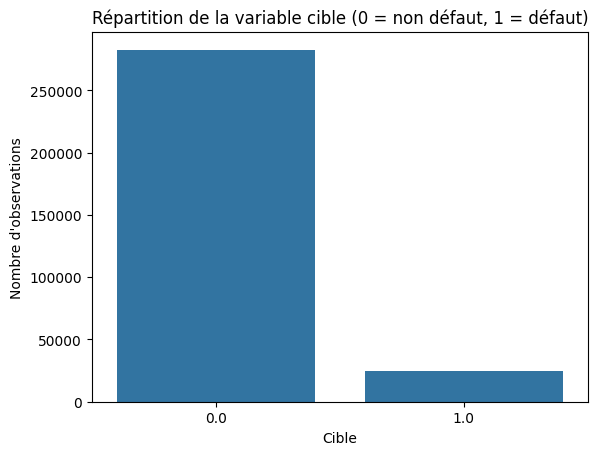

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fréquence brute
target_counts = y.value_counts()
target_ratio = y.value_counts(normalize=True)

print("Répartition cible (effectifs) :")
print(target_counts)

print("\nRépartition cible (%) :")
print((target_ratio * 100).round(2))

# Visualisation
sns.countplot(x=y)
plt.title("Répartition de la variable cible (0 = non défaut, 1 = défaut)")
plt.xlabel("Cible")
plt.ylabel("Nombre d'observations")
plt.show()

In [38]:
def taux_defaut_par_categorie(df, var, target="TARGET"):
    tab = df.groupby(var)[target].agg(["mean", "count"])
    tab.columns = ["taux_defaut", "effectif"]
    return tab.sort_values(by="taux_defaut", ascending=False)

# Exemple sur FLAG_OWN_CAR (si conservé après encodage)
# taux_defaut_par_categorie(df_train_cleaned, "FLAG_OWN_CAR")

In [40]:
# Calcul des corrélations
correlations = df_train_cleaned.corr()["TARGET"].drop("TARGET").sort_values(ascending=False)

# Affichage des plus fortes
print("Corrélation positive les plus fortes avec TARGET :")
print(correlations.head(10))

print("\nCorrélation négative les plus fortes avec TARGET :")
print(correlations.tail(10))

Corrélation positive les plus fortes avec TARGET :
DAYS_BIRTH                                         0.078242
DAYS_EMPLOYED                                      0.074957
REGION_RATING_CLIENT_W_CITY                        0.060895
REGION_RATING_CLIENT                               0.058901
NAME_INCOME_TYPE_Working                           0.057483
DAYS_LAST_PHONE_CHANGE                             0.055219
DAYS_ID_PUBLISH                                    0.051457
REG_CITY_NOT_WORK_CITY                             0.050992
NAME_EDUCATION_TYPE_Secondary_secondary_special    0.049822
FLAG_EMP_PHONE                                     0.045984
Name: TARGET, dtype: float64

Corrélation négative les plus fortes avec TARGET :
NAME_CONTRACT_TYPE_nan           NaN
NAME_INCOME_TYPE_nan             NaN
NAME_EDUCATION_TYPE_nan          NaN
NAME_FAMILY_STATUS_nan           NaN
NAME_HOUSING_TYPE_nan            NaN
WEEKDAY_APPR_PROCESS_START_nan   NaN
ORGANIZATION_TYPE_nan            NaN
source_te

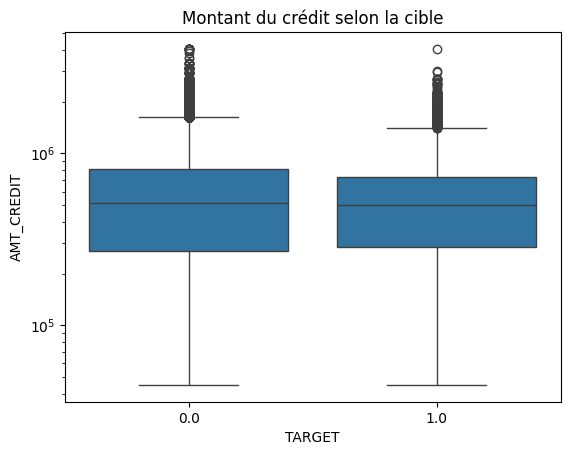

In [42]:
# Exemple : distribution AMT_CREDIT en fonction de la cible
if "AMT_CREDIT" in df_train_cleaned.columns:
    sns.boxplot(data=df_train_cleaned, x="TARGET", y="AMT_CREDIT")
    plt.title("Montant du crédit selon la cible")
    plt.yscale("log")
    plt.show()

# Score métier personnalisé & optimisation du seuil

In [45]:
from sklearn.metrics import confusion_matrix

def custom_cost_score(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(10 * fn + fp)

In [47]:
# Exemple de proba simulée
y_proba_simul = np.random.uniform(0, 1, size=len(y_val))
score_simule = custom_cost_score(y_val, y_proba_simul, threshold=0.5)

print("Score métier (simulé) :", score_simule)

Score métier (simulé) : -53393


In [49]:
import numpy as np
import matplotlib.pyplot as plt

def optimiser_seuil(y_true, y_proba):
    seuils = np.arange(0.1, 0.91, 0.01)
    scores = [-custom_cost_score(y_true, y_proba, t) for t in seuils]

    # Visualisation
    plt.figure(figsize=(10, 5))
    plt.plot(seuils, scores, marker='o')
    plt.title("Coût métier en fonction du seuil")
    plt.xlabel("Seuil de classification")
    plt.ylabel("Coût total (FN x10 + FP)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    idx_min = np.argmin(scores)
    return seuils[idx_min], scores[idx_min]

In [ ]:
# seuil_optimal, cout = optimiser_seuil(y_val, y_val_proba)
# with open(os.path.join(artifacts_path, "threshold_metier.txt"), "w") as f:
#     f.write(str(seuil_optimal))

# Entraînement des modèles de base

In [52]:
from sklearn.linear_model import LogisticRegression

# On retire les colonnes contenant des NaN pour ce modèle
X_train_lr = X_train.dropna(axis=1)
X_val_lr = X_val[X_train_lr.columns]

model_lr = LogisticRegression(solver='liblinear', random_state=42)
model_lr.fit(X_train_lr, y_train)

y_val_proba_lr = model_lr.predict_proba(X_val_lr)[:, 1]
score_lr = custom_cost_score(y_val, y_val_proba_lr)

print("LogisticRegression - Score métier :", score_lr)

LogisticRegression - Score métier : -49650


In [54]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

y_val_proba_rf = model_rf.predict_proba(X_val)[:, 1]
score_rf = custom_cost_score(y_val, y_val_proba_rf)

print("RandomForest - Score métier :", score_rf)

RandomForest - Score métier : -49621


In [56]:
from lightgbm import LGBMClassifier

model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(X_train, y_train)

y_val_proba_lgbm = model_lgbm.predict_proba(X_val)[:, 1]
score_lgbm = custom_cost_score(y_val, y_val_proba_lgbm)

print("LightGBM - Score métier :", score_lgbm)

C:\Users\chouh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Le fichier spécifié est introuvable
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\chouh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\chouh\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(e

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.186423 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13020
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
LightGBM - Score métier : -48761


In [58]:
results = {
    "LogisticRegression": score_lr,
    "RandomForest": score_rf,
    "LightGBM": score_lgbm
}

best_model_name = max(results, key=results.get)
print("Meilleur modèle avant optimisation :", best_model_name)

Meilleur modèle avant optimisation : LightGBM


# Optimisation du meilleur modèle (LightGBM)

In [61]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "num_leaves": [31, 64],
    "max_depth": [6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 300]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_grid=param_grid,
    scoring=custom_cost_score,
    refit=True,
    cv=cv,
    verbose=2,
    n_jobs=-1
)

In [63]:
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


C:\Users\chouh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.219692 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13020
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 31}


In [65]:
y_val_proba_best = grid_search.best_estimator_.predict_proba(X_val)[:, 1]
score_optimise = custom_cost_score(y_val, y_val_proba_best)

print("Score métier optimisé :", score_optimise)

Score métier optimisé : -49324


In [67]:
joblib.dump(grid_search.best_estimator_, os.path.join(artifacts_path, "best_model_lgbm_optimized.pkl"))
print("Modèle optimisé sauvegardé.")

Modèle optimisé sauvegardé.


# Interprétabilité avec SHAP

In [70]:
import shap

# Initialisation JS pour les visualisations (optionnel en notebook)
shap.initjs()

# Explainer LightGBM
explainer = shap.TreeExplainer(grid_search.best_estimator_)

C:\Users\chouh\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [72]:
# Échantillon pour accélérer le calcul
X_shap_sample = X_val.sample(500, random_state=42)

# Calcul des SHAP values
shap_values = explainer.shap_values(X_shap_sample)

C:\Users\chouh\anaconda3\Lib\site-packages\shap\explainers\_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


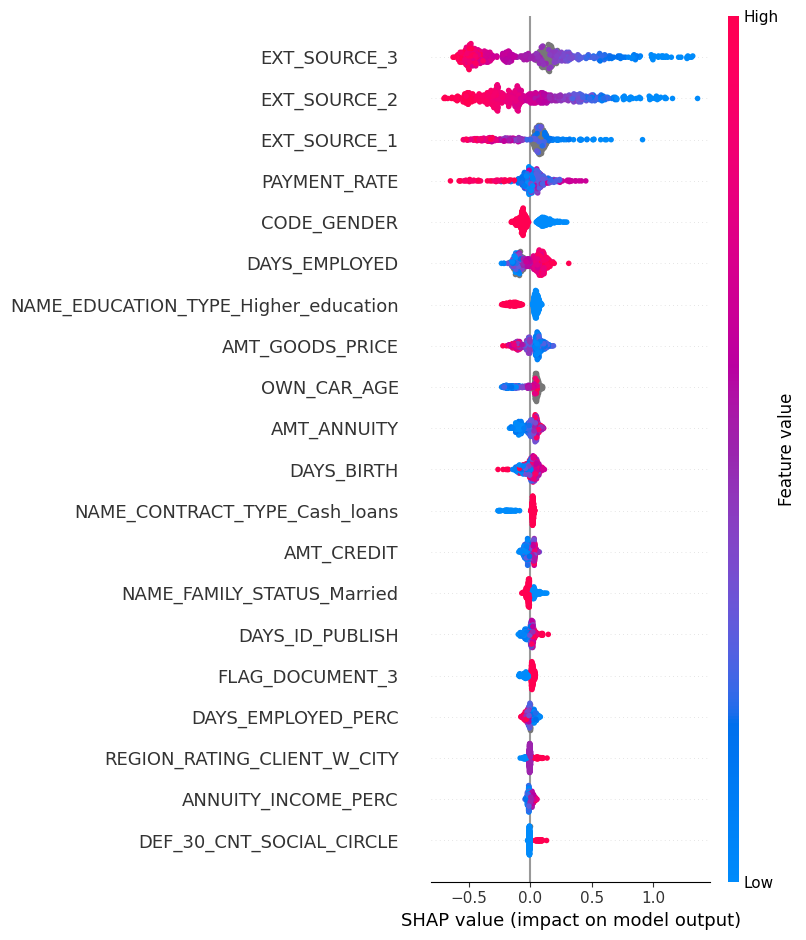

In [74]:
# Vue d'ensemble des variables les plus influentes
shap.summary_plot(shap_values, X_shap_sample)

In [76]:
# Moyenne absolue des SHAP values
shap_df = pd.DataFrame(shap_values, columns=X_shap_sample.columns)
mean_shap = shap_df.abs().mean().sort_values(ascending=False)

# Top 10 features
top_10_features = mean_shap.head(10).index.tolist()
print("Top 10 features SHAP :", top_10_features)

# Sauvegarde pour l’interface
joblib.dump(top_10_features, os.path.join(artifacts_path, "top_10_features.pkl"))

Top 10 features SHAP : ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'PAYMENT_RATE', 'CODE_GENDER', 'DAYS_EMPLOYED', 'NAME_EDUCATION_TYPE_Higher_education', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'AMT_ANNUITY']


['C:\\Users\\chouh\\Projet7\\artifacts\\top_10_features.pkl']

# Optimisation du seuil métier

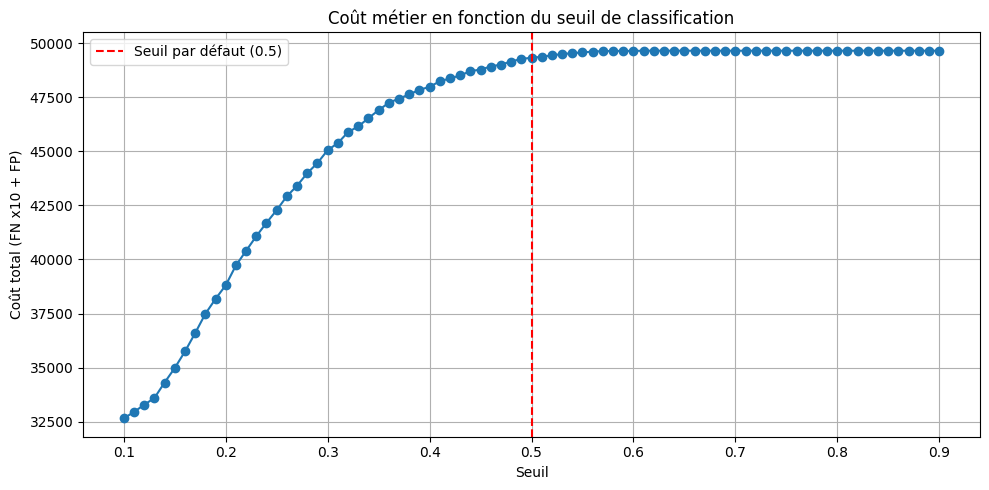

In [79]:
# Probabilités du modèle optimisé
y_val_proba = grid_search.best_estimator_.predict_proba(X_val)[:, 1]

seuils = np.arange(0.1, 0.91, 0.01)
costs = [-custom_cost_score(y_val, y_val_proba, t) for t in seuils]

plt.figure(figsize=(10, 5))
plt.plot(seuils, costs, marker='o')
plt.axvline(0.5, color='red', linestyle='--', label="Seuil par défaut (0.5)")
plt.title("Coût métier en fonction du seuil de classification")
plt.xlabel("Seuil")
plt.ylabel("Coût total (FN x10 + FP)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [81]:
best_idx = np.argmin(costs)
best_threshold = seuils[best_idx]
best_cost = costs[best_idx]

print("Seuil optimal :", best_threshold)
print("Coût minimal atteint :", best_cost)

Seuil optimal : 0.1
Coût minimal atteint : 32653


In [83]:
threshold_path = os.path.join(artifacts_path, "threshold_metier.txt")

with open(threshold_path, "w") as f:
    f.write(str(best_threshold))

print("Seuil métier optimal sauvegardé.")

Seuil métier optimal sauvegardé.


# Enregistrement final dans MLflow

In [86]:
# Exemple d'entrée issue du jeu de validation
input_example = X_val.iloc[[0]]

In [88]:
from mlflow.models.signature import infer_signature

y_example = grid_search.best_estimator_.predict_proba(input_example)
signature = infer_signature(input_example, y_example)

C:\Users\chouh\anaconda3\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


In [90]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("mlruns")  # Local tracking
mlflow.set_experiment("Credit_Scoring_Model")

with mlflow.start_run(run_name="LightGBM_Optimized") as run:
    mlflow.log_params(grid_search.best_params_)
    mlflow.sklearn.log_model(
        sk_model=grid_search.best_estimator_,
        artifact_path="model",
        registered_model_name="credit_scoring_model",
        input_example=input_example,
        signature=signature
    )
    print("Modèle loggué et enregistré dans le registry MLflow.")

2025/05/25 17:42:18 INFO mlflow.tracking.fluent: Experiment with name 'Credit_Scoring_Model' does not exist. Creating a new experiment.
2025/05/25 17:42:18 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    e

Modèle loggué et enregistré dans le registry MLflow.


Successfully registered model 'credit_scoring_model'.
Created version '1' of model 'credit_scoring_model'.


In [92]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
model_name = "credit_scoring_model"

latest_version = client.get_latest_versions(model_name, stages=["None"])[-1].version

client.transition_model_version_stage(
    name=model_name,
    version=latest_version,
    stage="Staging",
    archive_existing_versions=True
)

print(f"Version {latest_version} promue en Staging.")

Version 1 promue en Staging.


C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\3160248985.py:6: FutureWarning: ``mlflow.tracking.client.MlflowClient.get_latest_versions`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  latest_version = client.get_latest_versions(model_name, stages=["None"])[-1].version
C:\Users\chouh\AppData\Local\Temp\ipykernel_27444\3160248985.py:8: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
